**Objective:**


To create a **data-driven** YouTube channel and supporting platforms, **producing lo-fi, binaural beat, and study-focused** content by **integrating live-recorded drum performances with AI-generated melodic, harmonic, and ambient layers** within a collaborative **human–AI music production workflow**, while applying **machine learning models** to analyze historical YouTube trends and predict **potential content performance and audience engagement**.

<img src="neurobeat_logo.jpg" alt="description" width="400"/>

The goal is not to model YouTube as a whole, but to understand engagement dynamics within a highly specific content niche. For this scope, interpretability and feature relevance are prioritized over scale.

The model predicts expected audience engagement rather than virality, using content, temporal, and contextual features extracted from historical YouTube data.

**Engagement** is more stable and less dependent on channel size, which makes it **more appropriate for early-stage or niche** content such as study and *focus-oriented* videos.

- **Target Variable:** Engagement Score

**Content Features**
- video_duration_seconds
- title_length
- keyword (lofi / binaural / study_with_me)
- has_study_keyword (binary)
- has_binaural_keyword (binary)

**Temporal Features**
- publish_year
- publish_month
- days_since_upload (for early analysis)

**Channel-Level Features** *if available*
- channel_video_count
- channel_upload_frequency

**ML Model Type**
- Regression problem
- Baselines: Linear Regression
- Random Forest Regressor
- Gradient Boosting (optional upgrade)

Data to obtain from Google Cloud Console / **Create project** / YouTube Data API v3 / Generate API KEY


- video_id
- title
- description
- published_at
- channel_title
- view_count
- like_count
- comment_count
- duration
- keyword_used   (lofi / binaural / study with me)

This will help us obtain time-based trends, ML features, clear dashboards.

Keywords to search for:
- lofi
- lofi chill hop
- binaural beats
- study with me

Date range:
- publishedAfter
- publishedBefore

- 2016–2018
- 2019–2021
- 2022–2024
- 2025–2026 (If any)

**Example of first code snippet**

from googleapiclient.discovery import build
import pandas as pd

API_KEY = "MY_API_KEY"
youtube = build("youtube", "v3", developerKey=API_KEY)

def search_videos(query, published_after, published_before, max_results=50):
    request = youtube.search().list(
        q=query,
        part="snippet",
        type="video",
        publishedAfter=published_after,
        publishedBefore=published_before,
        maxResults=max_results
    )
    response = request.execute()
    return response["items"]


**To be used for video ID** / *Subject to change*

youtube.videos().list(
    part="statistics,contentDetails",
    id="ID1,ID2,ID3"
)

This in efforts to extract:

- views
- likes
- comments
- duration (ISO 8601 to be implemented later)

### 1) Library and Module import

In [ ]:
# Installing libraries

!pip install google-api-python-client


In [ ]:
from googleapiclient.discovery import build
import pandas as pd
import json
import time

### 2) API, YouTube Object and DF Definitions

In [ ]:
# Note: API key should be kept secret, and not hardcoded in production code
# Create a file and save it as .env, in it write: API_KEY=your_api_key_here
# Install the python-dotenv package if you want to load environment variables from a .env file

import os
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("API_KEY")

In [ ]:
# Building the YouTube service object

youtube = build(
    "youtube",
    "v3",
    developerKey=API_KEY
)

# Not having any errors up to this point indicates the API Key is valid

In [ ]:
def search_videos(
    keyword,
    published_after,
    published_before,
    max_results=50
):
    request = youtube.search().list(
        q=keyword,
        part="snippet",
        type="video",
        publishedAfter=published_after,
        publishedBefore=published_before,
        maxResults=max_results
    )
    
    response = request.execute()
    
    videos = []
    for item in response.get("items", []):
        videos.append({
            "video_id": item["id"]["videoId"],
            "title": item["snippet"]["title"],
            "description": item["snippet"]["description"],
            "published_at": item["snippet"]["publishedAt"],
            "channel_title": item["snippet"]["channelTitle"],
            "keyword_used": keyword
        })
        
    return pd.DataFrame(videos)


In [ ]:
df_test = search_videos(
    keyword="lofi",
    published_after="2016-01-01T00:00:00Z",
    published_before="2018-12-31T23:59:59Z",
    max_results=25
)

df_test.head()

In [ ]:
KEYWORDS = [
    "lofi",
    "lofi chill hop",
    "chillhop",
    "binaural beats",
    "study with me",
]


In [ ]:
DATE_RANGES = {
    "2016_2018": ("2016-01-01T00:00:00Z", "2018-12-31T23:59:59Z"),
    "2019_2021": ("2019-01-01T00:00:00Z", "2021-12-31T23:59:59Z"),
    "2022_2024": ("2022-01-01T00:00:00Z", "2024-12-31T23:59:59Z")
    }


In [ ]:
all_dfs = []

for period, (start_date, end_date) in DATE_RANGES.items():
    for keyword in KEYWORDS:
        df = search_videos(
            keyword=keyword,
            published_after=start_date,
            published_before=end_date,
            max_results=50
        )
        
        if not df.empty:
            df["period"] = period
            all_dfs.append(df)


In [ ]:
# Recreating the combined dataframe, deleted by mistake
all_dfs = []

for period, (start_date, end_date) in DATE_RANGES.items():
    for keyword in KEYWORDS:
        df_tmp = search_videos(
            keyword=keyword,
            published_after=start_date,
            published_before=end_date,
            max_results=50
        )

        if not df_tmp.empty:
            df_tmp["period"] = period
            all_dfs.append(df_tmp)

df_all = pd.concat(all_dfs, ignore_index=True)

df_all.shape


In [ ]:
df_all.columns


In [ ]:
video_ids = df_all["video_id"].unique().tolist()


In [ ]:
def get_video_stats(video_ids):
    request = youtube.videos().list(
        part="statistics,contentDetails",
        id=",".join(video_ids)
    )
    response = request.execute()

    stats = []
    for item in response.get("items", []):
        stats.append({
            "video_id": item["id"],
            "view_count": int(item["statistics"].get("viewCount", 0)),
            "like_count": int(item["statistics"].get("likeCount", 0)),
            "comment_count": int(item["statistics"].get("commentCount", 0)),
            "duration": item["contentDetails"]["duration"]
        })

    return pd.DataFrame(stats)


In [ ]:
all_stats = []

for i in range(0, len(video_ids), 50):
    batch = video_ids[i:i+50]
    batch_df = get_video_stats(batch)
    all_stats.append(batch_df)

df_stats = pd.concat(all_stats, ignore_index=True)


In [ ]:
df_stats.shape
df_stats.columns
# Result: (567, 5)
# These videos will suffice our need, our target is the level of engagement which comes from comments and likes, not the number of videos themselves.

In [ ]:
df_full = df_all.merge(df_stats, on="video_id", how="left")


In [ ]:
df_full["engagement"] = (
    df_full["like_count"] + df_full["comment_count"]
)

df_full["engagement_per_view"] = (
    df_full["engagement"] / df_full["view_count"]
)
df_full.head()

### **Re-cap before moving forward.**

- **df_all - Semantic DataFrame**
-   Shape: (650,7)
-   Search API, contains: 
- video_id
- title
- description
- published_at
- channel_title
- keyword_used
- period
- title_length

- **df_stats - Technical DataFrame**
-   Shape: (567, 5)
-   Statistics API, contains: 
-   video_id
-   view_count
-   like_count
-   comment_count
-   duration


In [ ]:
# Creating the final dataframe
df_full = df_all.merge(df_stats, on="video_id", how="left")
df_full.shape

**df_all - Semantic**
- Raw structure of the object, focuses on on data shape and abbreviated column names, specific data types. 

**df_stats - Technical**
- Business meaning of the data enriched and transformed for better readibility. 

**df_full - Final project dataset**
- Shape: (650, 11) - It allows us to:
- Calculate engagement
- Filter
- Perform EDA
- Train models

### 3) Visualizations

In [ ]:
# Distribution of videos per keyword
import matplotlib.pyplot as plt

df_all['keyword_used'].value_counts().plot(kind='bar')
plt.title("Number of videos per keyword")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_all["year"] = pd.to_datetime(df_all["published_at"]).dt.year


In [ ]:
# Video count over time by keyword
df_all.groupby(['year', 'keyword_used']).size().unstack().plot(figsize=(10,5))
plt.title("Video count over time by keyword")
plt.ylabel("Number of videos")
plt.show()


In [ ]:
# Title length by content type
df_all['title_length'] = df_all['title'].str.len()

df_all.boxplot(column='title_length', by='keyword_used', figsize=(10,5))
plt.title("Title length by content type")
plt.suptitle("")
plt.ylabel("Characters")
plt.show()


In [ ]:
df_all.groupby("keyword_used")["title_length"].describe()

### 4) Preparation and training for ML Model

In [ ]:
df_full = df_full[df_full["view_count"] > 0].copy()


In [ ]:
! pip install isodate

In [ ]:
import isodate

df_full["video_duration_seconds"] = df_full["duration"].apply(
    lambda x: isodate.parse_duration(x).total_seconds()
)


In [ ]:
df_full["title_length"] = df_full["title"].str.len()


In [ ]:
df_full["engagement"] = (
    df_full["like_count"] + df_full["comment_count"]
)

df_full["engagement_per_view"] = (
    df_full["engagement"] / df_full["view_count"]
)


In [ ]:
# Correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "view_count",
    "like_count",
    "comment_count",
    "video_duration_seconds",
    "title_length",
    "engagement_per_view"
]

corr_matrix = df_full[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


The correlation analysis shows that raw popularity metrics such as **views, likes and comments** are strongly correlated with each other, but show almost no correlation with engagement per view.

**Engagement per view appears to be a different behavioral signal**, slightly negatively correlated with video duration and title length, which suggests that longer videos and longer titles tend to generate lower relative interaction per viewer.

Longer videos work best for consumption more so than interaction and engagement, which works best and fits the purpose for our LoFi domain. 

In [ ]:
df_full["year"] = pd.to_datetime(df_full["published_at"]).dt.year
df_full.columns



In [ ]:
features = [ "video_duration_seconds", "title_length", "year", "keyword_used" ]
X = df_full[features]
y = df_full["engagement_per_view"]

In [ ]:
# Three numerical features: video_duration_seconds, title_length, year
# Target: engagement_per_view

df_model = df_full[df_full["view_count"] >= 100].copy()

In [ ]:
features = [
    "video_duration_seconds",
    "title_length",
    "year"
]

X = df_model[features]
y = df_model["engagement_per_view"]


In [ ]:
import numpy as np

mask = np.isfinite(y)

X = X.loc[mask]
y = y.loc[mask]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)


These were the expected results, these variables carry little-to-no predicitive power on their own as seen in the heat map.
This is the point where we add our keyword.

In [ ]:
features = [
    "video_duration_seconds",
    "title_length",
    "year",
    "keyword_used"
]

X = df_model[features]
y = df_model["engagement_per_view"]

X = pd.get_dummies(X, columns=["keyword_used"], drop_first=True)

mask = np.isfinite(y)

X = X.loc[mask]
y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression() # Linear Regression, will try Random Forest next
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


After adding the keywords, our R2 result jumped from 0.14 (14%) to 0.36 (36%). Adding content-type information (lofi, chillhop, binaural beats, study-with-me) significantly improves the predictive performance compared to using only temporal and structural metadata.

In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef_df


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Coef plot based on results above

# Visual settings
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Bar graph
ax = sns.barplot(
    data=coef_df, 
    x="coef", 
    y="feature", 
    palette="vlag" # Divergent: Blue for negatives, red for positives
)

# Adding a line at zero for clarity
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Titles
plt.title("Feature Coefficients: Impact on Prediction", fontsize=15)
plt.xlabel("Coefficient Value (Weight)", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.show()


In [ ]:
pd.get_dummies(df_full["keyword_used"]).columns


In [ ]:
features = [
    "title_length",
    "video_duration_seconds",
    "year",
    "keyword_used"
]

X = df_full[features]
y = df_full["engagement_per_view"]


In [ ]:
X = pd.get_dummies(
    df_full[[
        "title_length",
        "video_duration_seconds",
        "year",
        "keyword_used"
    ]],
    columns=["keyword_used"],
    drop_first=True
)

y = df_full["engagement_per_view"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)


In [ ]:
# Importing feature importance function

import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances


In [ ]:
import matplotlib.pyplot as plt

importances.plot(kind="barh", figsize=(8,6))
plt.title("Random Forest - Feature importance")
plt.gca().invert_yaxis()
plt.show()


The most informative feature for predicting engagement per view is video duration, followed by title length and publication year. Content category (keyword) contributes only marginally.

- **🥇 1. video_duration_seconds → 65.7%**
Without this feature the model loses capacity to predict.
- **🥈 2. title_length → 16.1%**
Video lenght helps the model separating engagement behaviour.
- **🥉 3. year → 7.4%**
YouTube is not the same as it used to back in YouTube 2016, so adding this feature brings relevance to our model.

- Videos under the *Study with me* category help the model understand the *engagement_per_view*

### So far we have covered: 

- 💻API Extraction
- 🧹Data cleaning
- 🔧Feature Engineering
- 🎯Well-defined target variable
- 🛤️ Model - Linear Regression
- 🌳🌲Non-linear model - Random Forest
- 🧐Model Interpretation

Predicting the engagement_per_view based on a limited dataset is not an easy task, nonetheless, we managed to achieve solid results using two ML models. 
Some of the details we did not have include: 


- Thumbnail
- Audio quality
- Video quality
- Channel
- Subscriber Count
- Posting time
- True niche
- Competetion on posting date

We want to push our model further, and will include the following features:

- Subscriber Count
- Channel VideoCount
- Channel total views

### 5) RandomForest 2.0

Including: 
- Subscriber Count
- Channel VideoCount
- Channel total views

In [ ]:
# Getting Chnnel ID from video ID

def get_video_channels(video_ids):
    rows = []

    for i in range(0, len(video_ids), 50):
        batch = video_ids[i:i+50]

        request = youtube.videos().list(
            part="snippet",
            id=",".join(batch)
        )
        response = request.execute()

        for item in response.get("items", []):
            rows.append({
                "video_id": item["id"],
                "channel_id": item["snippet"]["channelId"]
            })

    return pd.DataFrame(rows)


In [ ]:
# Executing the function
video_ids = df_full["video_id"].unique().tolist()

df_video_channels = get_video_channels(video_ids)


In [ ]:
# Merging channel IDs into the main df_full dataframe
df_full = df_full.merge(df_video_channels, on="video_id", how="left")


In [ ]:
# Getting channel statistics
def get_channel_stats(channel_ids):
    rows = []

    for i in range(0, len(channel_ids), 50):
        batch = channel_ids[i:i+50]

        request = youtube.channels().list(
            part="statistics",
            id=",".join(batch)
        )
        response = request.execute()

        for item in response.get("items", []):
            stats = item["statistics"]

            rows.append({
                "channel_id": item["id"],
                "subscriber_count": int(stats.get("subscriberCount", 0)),
                "channel_view_count": int(stats.get("viewCount", 0)),
                "channel_video_count": int(stats.get("videoCount", 0))
            })

    return pd.DataFrame(rows)


In [ ]:
# Executing the function
channel_ids = df_full["channel_id"].dropna().unique().tolist()

df_channels = get_channel_stats(channel_ids)


In [ ]:
# Final merge of channel stats into df_full
df_full = df_full.merge(df_channels, on="channel_id", how="left")

In [ ]:
# Checking the final dataframe
df_full[
    [
        "subscriber_count",
        "channel_video_count",
        "channel_view_count"
    ]
].describe()


In [ ]:
# "Planting" RandomForest model with new features
X = pd.get_dummies(
    df_full[[
        "title_length",
        "video_duration_seconds",
        "year",
        "subscriber_count",
        "channel_video_count",
        "channel_view_count",
        "keyword_used"
    ]],
    columns=["keyword_used"],
    drop_first=True
)

y = df_full["engagement_per_view"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(X_train, y_train)


In [ ]:
y_pred = rf_v2.predict(X_test)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RandomForest V2.0 R2: {r2:.4f}")
print(f"RandomForest V2.0 MAE: {mae:.6f}")


In [ ]:
comparison = pd.DataFrame({
    "Model": ["RF V1", "RF V2"],
    "R2": [0.1674, 0.3219],
    "MAE": [0.005251, 0.004379]
})

comparison


### RandomForest V2 - Results
There is a clear improvement after including new features to support our model. 

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_v2.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance


In [ ]:
import matplotlib.pyplot as plt

# Feature importance plot
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)
plt.gca().invert_yaxis()
plt.title("Random Forest V2 – Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Channel-level** variables dominate feature importance, indicating that engagement is more strongly driven by **creator scale** than individual video characteristics.

In [ ]:
import numpy as np
# Creating log-transformed features
df_full["log_subscriber_count"] = np.log1p(df_full["subscriber_count"])
df_full["log_channel_view_count"] = np.log1p(df_full["channel_view_count"])

In [ ]:
# Raw-free X and y

X_v21 = pd.get_dummies(
    df_full[
        [
            "title_length",
            "video_duration_seconds",
            "year",
            "log_subscriber_count",
            "log_channel_view_count",
            "channel_video_count",
            "keyword_used"
        ]
    ],
    columns=["keyword_used"],
    drop_first=True
)

y = df_full["engagement_per_view"]


In [ ]:
# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_v21,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Training RF V2.1 Model
from sklearn.ensemble import RandomForestRegressor

rf_v21 = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf_v21.fit(X_train, y_train)


In [ ]:
# Evaluating RF V2.1 model
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf_v21.predict(X_test)

print("RandomForest V2.1")
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


In [ ]:
# Comparing all three models

comparison = pd.DataFrame({
    "Model": ["RF V1", "RF V2" , "RF V2.1"],
    "R2": [0.1674, 0.3219, 0.3456],
    "MAE": [0.005251, 0.004379, 0.004123]
})

comparison

# Slight improvement with log-transformed features

6) ### SHAP - SHapley Additive exPlanations

In [132]:
# Installing SHAP library for explainability
!pip install shap


In [133]:
# Importing SHAP library
import shap
import numpy as np

shap.initjs() 

In [134]:
# Creating SHAP explainer and calculating SHAP values
explainer = shap.TreeExplainer(rf_v21)
shap_values = explainer.shap_values(X_test)

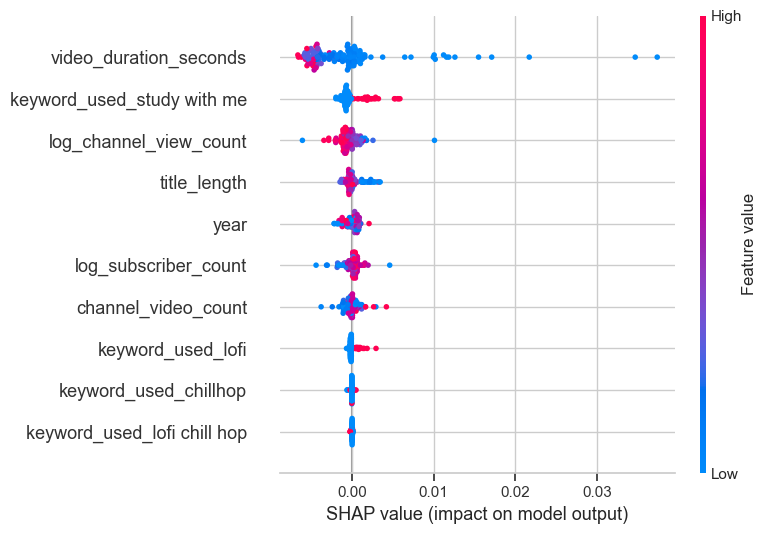

In [128]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test)

In [126]:
# SHAP for single video
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

# Based on SHAP analysis, "STUDY WITH ME" key feature is influencing engagement per view 

Although the video uses a high-performing keyword (**‘study with me’**), its long duration and the channel’s high volume of uploaded content reduce the expected engagement per view, resulting in a prediction below the dataset average.

### Machine Learnig - Final Conclusion

- Predicting YouTube engagement is inherently complex due to **hidden platform dynamics and algorithmic exposure**;
- Models trained only on video-level features significantly underperform;
- Introducing channel-level context nearly **doubled predictive performance**, validating the hypothesis that **creator scale is a dominant factor**;
- Tree-based models like **Random Forest** captured non-linear interactions effectively;
- SHAP values revealed that subscriber count and channel reach consistently drive engagement, while video characteristics play a secondary role;
- As expected, **Random Forest** offered the best trade-off between performance, stability, and explainability.

### We close the ML-Section of the project with: 

- API Extraction
- Data cleaning
- Feature Engineering
- Well-defined target variable
- Model - Linear Regression
- Non-linear model - Random Forest
- Model Interpretation
- Refined features for RandomForest model
- Model Comparison

#### Next-up: Binaural Beat Generator

### 7) Binaural Beat Generator

In [ ]:
import numpy as np
from scipy.io.wavfile import write
from IPython.display import Audio

# Parameters
duration = 60.0   # seconds
fs = 44100        # sampling rate
freq_left = 100   # Hz
freq_right = 120  # Hz
volume = 0.05    # safe for ears

# Time array
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

# Generate sine waves for left and right ears
left_tone = np.sin(2 * np.pi * freq_left * t)
right_tone = np.sin(2 * np.pi * freq_right * t)

# Stereo signal (left, right)
stereo_signal = np.vstack((left_tone, right_tone)).T * volume

# Convert to int16 for WAV
stereo_signal_int16 = (stereo_signal * 32767).astype(np.int16)

# === Save as WAV ===
write("binaural_test.wav", fs, stereo_signal_int16)
print("✅ Exported binaural beat to binaural_test.wav")

# === Playable widget ===
Audio("binaural_test.wav")
